ABDULLAH

SU92-BSAIM-F24-002

BSAI-4A

PROGRAMMING FOR ARTIFICIAL INTELLIGENCE

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


Load Dataset:

In [7]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.head())
print(train.info())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
<c

EDA (Exploratory Data Analysis):

In [8]:
print(train.isnull().sum())


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


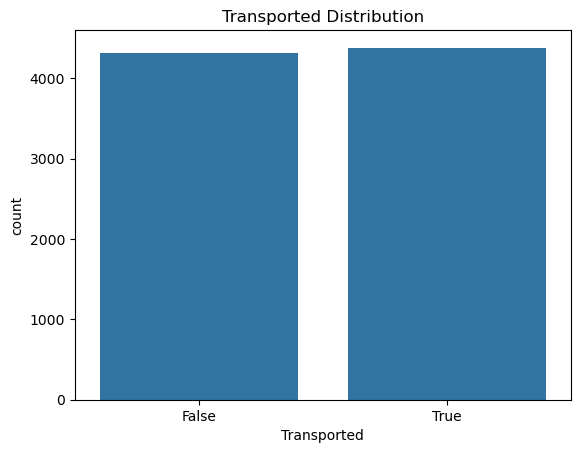

In [9]:
sns.countplot(x="Transported", data=train)
plt.title("Transported Distribution")
plt.show()


Correlation Heatmap:

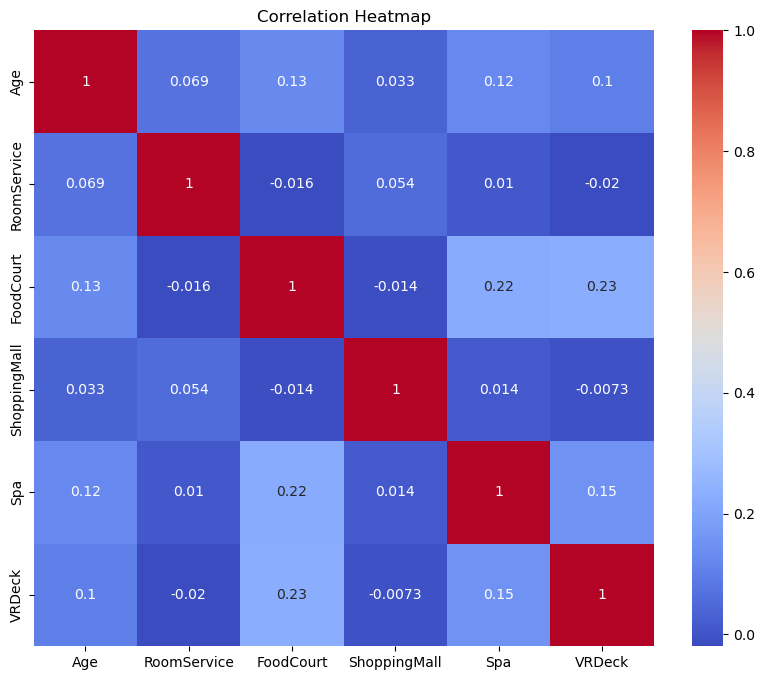

In [10]:
numeric_train = train.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Data Preprocessing:

In [11]:
X = train.drop("Transported", axis=1)
y = train["Transported"]


In [12]:
X = X.drop(["PassengerId", "Name"], axis=1)
test_ids = test["PassengerId"]
test = test.drop(["PassengerId", "Name"], axis=1)


In [13]:
X["Cabin_deck"] = X["Cabin"].str.split("/").str[0]
test["Cabin_deck"] = test["Cabin"].str.split("/").str[0]

X = X.drop("Cabin", axis=1)
test = test.drop("Cabin", axis=1)


In [18]:
for col in X.columns:
    if X[col].dtype == "object" or X[col].dtype == "bool":
        X[col] = X[col].fillna("Unknown").astype(str)
        test[col] = test[col].fillna("Unknown").astype(str)
    else:
        X[col] = X[col].fillna(X[col].median())
        test[col] = test[col].fillna(test[col].median())


Preprocessing Pipeline:

In [19]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object','bool']).columns


In [20]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


Model Training:-

In [21]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model)
])

pipeline.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

Evaluation:-

In [22]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print("Cross Validation Accuracy:", scores.mean())


Cross Validation Accuracy: 0.7866118180957933


Train/Test Split Evaluation:-

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Validation Accuracy: 0.7791834387579069
              precision    recall  f1-score   support

       False       0.78      0.78      0.78       861
        True       0.78      0.78      0.78       878

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



Improve Model:-

In [24]:
param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20]
}

grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best Accuracy: 0.7951239627486419


Make Submission:-

In [25]:
best_model = grid.best_estimator_

predictions = best_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": predictions
})

submission.to_csv("submission.csv", index=False)
